# Laboratório de Sistemas Dinâmicos Não Lineares

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nolds

from scipy.integrate import solve_ivp
from scipy.optimize import root, root_scalar
from scipy.spatial import cKDTree, distance_matrix

rng = np.random.default_rng(2026)
np.set_printoptions(precision=5, suppress=True)

%matplotlib inline

print("Ambiente carregado.")

Ambiente carregado.


# Parte A — Um sistema contínuo de feedback umidade–vegetação

Começaremos com um sistema contínuo de duas variáveis.

$$
\dot m=P+\alpha v-\beta m,
$$

$$
\dot v=v\left[r(1-v)\frac{m}{h+m}-d\right].
$$

Sendo:

- $m(t)$: índice adimensional de disponibilidade de umidade;
- $v(t)$: índice adimensional de condição/cobertura vegetal;
- $P$: entrada externa de umidade;
- $\alpha v$: retroalimentação positiva da vegetação sobre a umidade;
- $\beta m$: perda de umidade;
- $r$: intensidade máxima da resposta da vegetação;
- $h$: escala de saturação da resposta à umidade;
- $d$: perda/mortalidade efetiva.

O termo $m/(h+m)$ é uma resposta saturante: aumentar a umidade ajuda muito quando $m$ é pequeno, mas o ganho marginal diminui quando $m$ já é grande.

## A.1 Equilíbrios e um limiar analítico

Um equilíbrio satisfaz

$$
\dot m=0,\qquad \dot v=0.
$$

Existe sempre o equilíbrio sem vegetação

$$
E_0=\left(\frac{P}{\beta},0\right).
$$

Para estudar sua estabilidade, olhamos a Jacobiana. No ponto $v=0$, um dos autovalores é simplesmente $-\beta<0$. O outro é

$$
\lambda_v=r\frac{m}{h+m}-d,
\quad m=\frac{P}{\beta}.
$$

A troca de estabilidade ocorre quando $\lambda_v=0$:

$$
r\frac{P/\beta}{h+P/\beta}=d.
$$

Isolando $P$:

$$
\boxed{P_c=\frac{\beta d h}{r-d}}.
$$

In [2]:
# Célula 2 — parâmetros do modelo contínuo
params_c = {
    "alpha": 0.10,
    "beta": 0.80,
    "r": 1.60,
    "h": 0.25,
    "d": 0.45,
}

alpha, beta, r, h, d = [params_c[k] for k in ["alpha", "beta", "r", "h", "d"]]
P_c = beta * d * h / (r - d)
print(f"Limiar analítico P_c = {P_c:.5f}")

Limiar analítico P_c = 0.07826


In [3]:
# Célula 3 — campo vetorial, Jacobiana e equilíbrios

def rhs_cont(t, z, P, alpha=alpha, beta=beta, r=r, h=h, d=d):
    m, v = z
    dm = P + alpha*v - beta*m
    dv = v*(r*(1-v)*m/(h+m) - d)
    return np.array([dm, dv])


def jac_cont(z, P, alpha=alpha, beta=beta, r=r, h=h, d=d):
    m, v = z
    dq_dm = h/(h+m)**2
    J = np.array([
        [-beta, alpha],
        [r*v*(1-v)*dq_dm,
         r*(1-2*v)*m/(h+m) - d]
    ])
    return J


def equilibrium_cont(P, guess=(0.7, 0.5)):
    sol = root(lambda z: rhs_cont(0, z, P), guess)
    return sol

for P in [0.05, 0.25]:
    E0 = np.array([P/beta, 0.0])
    eig0 = np.linalg.eigvals(jac_cont(E0, P))
    sol = equilibrium_cont(P)
    print(f"P={P:.2f}: E0={E0}, autovalores(E0)={eig0}")
    if sol.success:
        print("  equilíbrio encontrado numericamente:", sol.x,
              "autovalores:", np.linalg.eigvals(jac_cont(sol.x, P)))

P=0.05: E0=[0.0625 0.    ], autovalores(E0)=[-0.8 +0.j -0.13+0.j]
  equilíbrio encontrado numericamente: [ 0.0625 -0.    ] autovalores: [-0.8 +0.j -0.13+0.j]
P=0.25: E0=[0.3125 0.    ], autovalores(E0)=[-0.8    +0.j  0.43889+0.j]
  equilíbrio encontrado numericamente: [0.37916 0.53331] autovalores: [-0.87058+0.j -0.44366+0.j]


Para sistemas contínuos, temos que: 

$$
Re(\lambda) \lt 0 \rightarrow \text{Estável}
$$

$$
Re(\lambda) \gt 0 \rightarrow \text{Instável}
$$

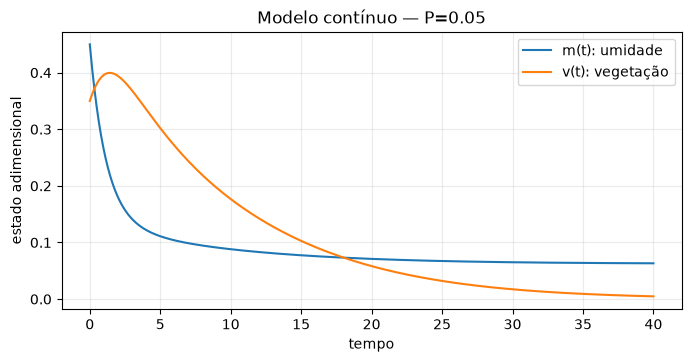

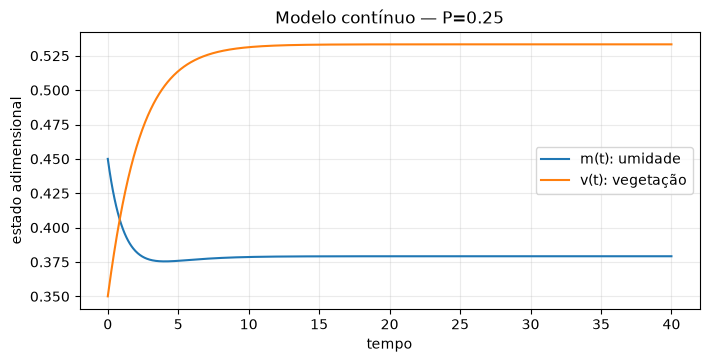

In [4]:
# Célula 4 — duas simulações: abaixo e acima do limiar

def simulate_cont(P, z0=(0.45, 0.35), tmax=40):
    t_eval = np.linspace(0, tmax, 1000)
    sol = solve_ivp(rhs_cont, (0, tmax), z0, args=(P,), t_eval=t_eval,
                    rtol=1e-9, atol=1e-11)
    return sol

for P in [0.05, 0.25]:
    sol = simulate_cont(P)
    fig, ax = plt.subplots(figsize=(8, 3.6))
    ax.plot(sol.t, sol.y[0], label="m(t): umidade")
    ax.plot(sol.t, sol.y[1], label="v(t): vegetação")
    ax.set_title(f"Modelo contínuo — P={P:.2f}")
    ax.set_xlabel("tempo")
    ax.set_ylabel("estado adimensional")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.show()

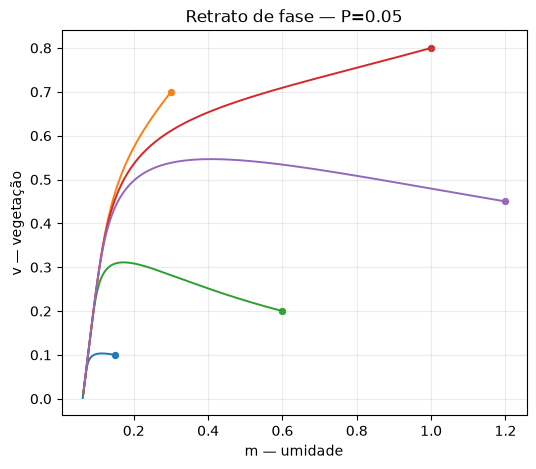

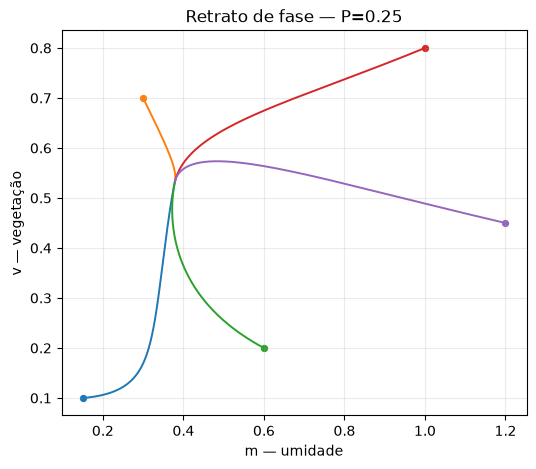

In [5]:
# Célula 5 — retrato de fase para vários estados iniciais

def phase_portrait_cont(P, initials):
    fig, ax = plt.subplots(figsize=(6, 5))
    for z0 in initials:
        sol = simulate_cont(P, z0=z0, tmax=35)
        ax.plot(sol.y[0], sol.y[1], lw=1.4)
        ax.scatter(sol.y[0,0], sol.y[1,0], s=18)
    ax.set_xlabel("m — umidade")
    ax.set_ylabel("v — vegetação")
    ax.set_title(f"Retrato de fase — P={P:.2f}")
    ax.grid(alpha=0.25)
    plt.show()

initials = [(0.15,0.1),(0.3,0.7),(0.6,0.2),(1.0,0.8),(1.2,0.45)]
phase_portrait_cont(0.05, initials)
phase_portrait_cont(0.25, initials)

## A.2 Diagrama de equilíbrio versus parâmetro

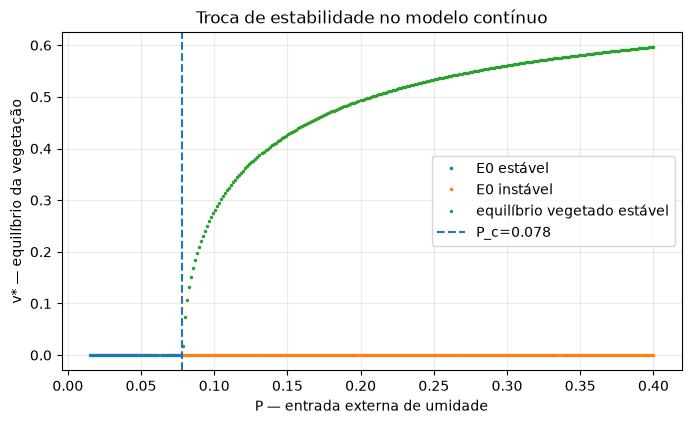

In [30]:
# Célula 6 — ramo de equilíbrios e troca de estabilidade
Ps = np.linspace(0.015, 0.40, 280)
E0_v = np.zeros_like(Ps)
E0_stable = []
pos_v = np.full_like(Ps, np.nan)
pos_stable = np.full_like(Ps, False, dtype=bool)

# Primeiro: estabilidade do ramo v=0
for P in Ps:
    E0 = np.array([P/beta, 0.0])
    eig0 = np.linalg.eigvals(jac_cont(E0, P))
    E0_stable.append(np.max(np.real(eig0)) < 0)
E0_stable = np.array(E0_stable)

# Segundo: seguimos o ramo vegetado de P alto para P baixo.
# Isso evita que o resolvedor fique preso no equilíbrio trivial v=0.
last_guess = np.array([0.4, 0.5])
for idx in range(len(Ps)-1, -1, -1):
    P = Ps[idx]
    sol = root(lambda z: rhs_cont(0, z, P), last_guess)
    if sol.success:
        m_eq, v_eq = sol.x
        last_guess = sol.x
        if v_eq > 1e-6:
            pos_v[idx] = v_eq
            pos_stable[idx] = np.max(np.real(np.linalg.eigvals(jac_cont(sol.x, P)))) < 0

fig, ax = plt.subplots(figsize=(8,4.4))
ax.plot(Ps[E0_stable], E0_v[E0_stable], '.', ms=3, label="E0 estável")
ax.plot(Ps[~E0_stable], E0_v[~E0_stable], '.', ms=3, label="E0 instável")
mask = np.isfinite(pos_v)
ax.plot(Ps[mask & pos_stable], pos_v[mask & pos_stable], '.', ms=3, label="equilíbrio vegetado estável")
ax.axvline(P_c, ls='--', label=f"P_c={P_c:.3f}")
ax.set_xlabel("P — entrada externa de umidade")
ax.set_ylabel("v* — equilíbrio da vegetação")
ax.set_title("Troca de estabilidade no modelo contínuo")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

# Parte B — Um mapa discreto não linear com memória

Considere um índice ambiental normalizado $x_n\in(0,1)$ e o mapa de dois estados

$$
x_{n+1}=S\left[b+\mu x_n(1-x_n)-\kappa x_{n-1}\right],
$$

$$
y_{n+1}=x_n,\qquad y_n=x_{n-1},
$$

onde

$$
S(q)=\frac{1}{1+e^{-a q}}
$$

é uma função sigmoide.

Sendo:

- $x_n$: índice agregado de estado floresta–atmosfera no instante $n$;
- $\mu x_n(1-x_n)$: retroalimentação não linear do estado atual;
- $-\kappa x_{n-1}$: memória/efeito retardado do estado anterior;
- $b$: forçamento basal;
- $S$: saturação que mantém o índice entre 0 e 1.

Memória: embora observemos uma única variável $x_n$, o estado completo é bidimensional,

$$
\mathbf z_n=(x_n,x_{n-1}).
$$

Isso criará uma ponte natural para reconstrução de espaço de fases a partir de uma série escalar.

In [7]:
# Célula 7 — definição do mapa discreto
A_SIG = 2.0
KAPPA = 1.0
B = -0.40


def sigmoid(q, a=A_SIG):
    q = np.asarray(q)
    return 1/(1+np.exp(-a*q))


def F_map(z, mu, kappa=KAPPA, b=B, a=A_SIG):
    x, y = z
    q = b + mu*x*(1-x) - kappa*y
    xn = 1/(1+np.exp(-a*q))
    return np.array([xn, x])


def J_map(z, mu, kappa=KAPPA, b=B, a=A_SIG):
    x, y = z
    q = b + mu*x*(1-x) - kappa*y
    s = 1/(1+np.exp(-a*q))
    ds_dq = a*s*(1-s)
    return np.array([
        [ds_dq*mu*(1-2*x), -ds_dq*kappa],
        [1.0, 0.0]
    ])


def simulate_map(mu, z0=(0.30, 0.31), n=2500, discard=0):
    z = np.array(z0, dtype=float)
    traj = np.empty((n,2))
    for i in range(n):
        traj[i] = z
        z = F_map(z, mu)
    return traj[discard:]

## B.1 Ponto fixo e Jacobiana

Um ponto fixo satisfaz $x_{n+1}=x_n=x_{n-1}=x^*$. Portanto,

$$
x^*=S\left[b+\mu x^*(1-x^*)-\kappa x^*\right].
$$

Não precisamos obter uma fórmula fechada para $x^*$. Podemos resolver essa equação numericamente.

A Jacobiana do mapa no estado $(x,y)$ é

$$
J(x,y)=
\begin{pmatrix}
S'(q)\mu(1-2x) & -S'(q)\kappa\\
1 & 0
\end{pmatrix},
$$

com

$$
S'(q)=aS(q)[1-S(q)].
$$

Para um mapa discreto, o ponto fixo é localmente assintoticamente estável se todos os autovalores da Jacobiana estão **dentro do círculo unitário**:

$$
\boxed{|\lambda_i|<1.}
$$

Essa é exatamente a passagem do critério unidimensional $|f'(x^*)|<1$ para várias dimensões.

In [8]:
# Célula 8 — pontos fixos e estabilidade para alguns valores de mu

def fixed_point_map(mu, guess=0.5):
    fun = lambda x: x - sigmoid(B + mu*x*(1-x) - KAPPA*x)
    # root escalar com chute via método híbrido do scipy.root
    sol = root(lambda q: fun(q[0]), [guess])
    xstar = float(sol.x[0])
    zstar = np.array([xstar, xstar])
    eig = np.linalg.eigvals(J_map(zstar, mu))
    return xstar, eig

rows=[]
for mu in [7.0, 8.0, 10.0, 11.5, 12.5, 14.0]:
    xstar, eig = fixed_point_map(mu)
    rows.append({
        "mu": mu,
        "x*": xstar,
        "lambda_1": eig[0],
        "lambda_2": eig[1],
        "rho(J)": np.max(np.abs(eig)),
        "fixo_estavel?": np.max(np.abs(eig)) < 1
    })

pd.DataFrame(rows)

,mu,x*,lambda_1,lambda_2,rho(J),fixo_estavel?
0,7.0,0.691205,-0.571353+0.316918j,-0.571353-0.316918j,0.653362,True
1,8.0,0.722925,-1.045845+0.000000j,-0.383048+0.000000j,1.045845,False
2,10.0,0.769658,-1.704190+0.000000j,-0.208057+0.000000j,1.704190,False
3,11.5,0.795142,-2.052796+0.000000j,-0.158702+0.000000j,2.052796,False
4,12.5,0.809061,-2.249884+0.000000j,-0.137324+0.000000j,2.249884,False
5,14.0,0.826541,-2.507365+0.000000j,-0.114360+0.000000j,2.507365,False


Quando o ponto fixo perde estabilidade, isso não significa necessariamente que a trajetória diverge para infinito. Como o mapa é limitado pela sigmoide, podem surgir ciclos, bandas aperiódicas e outros atratores.

Essa é uma diferença conceitual importante entre “o equilíbrio ficou instável” e “o sistema ficou sem dinâmica organizada”. Muitas vezes a perda de estabilidade de um atrator abre caminho para outro.

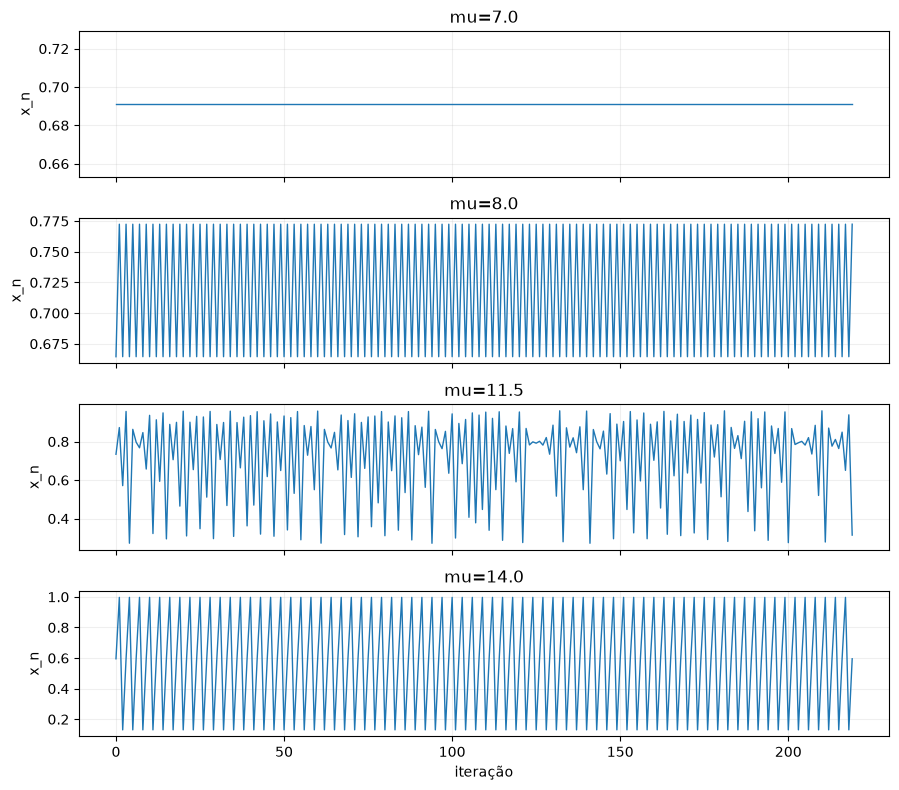

In [9]:
# Célula 9 — séries temporais em regimes diferentes
mus_demo = [7.0, 8.0, 11.5, 14.0]

fig, axes = plt.subplots(len(mus_demo), 1, figsize=(9,8), sharex=True)
for ax, mu in zip(axes, mus_demo):
    tr = simulate_map(mu, n=900, discard=300)
    ax.plot(tr[:220,0], lw=1)
    ax.set_ylabel("x_n")
    ax.set_title(f"mu={mu}")
    ax.grid(alpha=0.2)
axes[-1].set_xlabel("iteração")
plt.tight_layout()
plt.show()

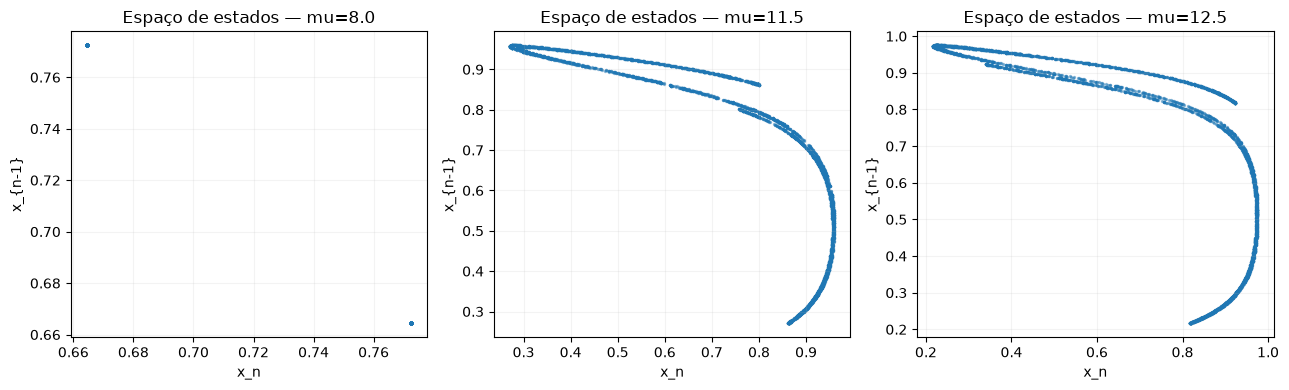

In [10]:
# Célula 10 — retratos de fase do mapa: (x_n, x_{n-1})
fig, axes = plt.subplots(1, 3, figsize=(13,4))
for ax, mu in zip(axes, [8.0, 11.5, 12.5]):
    tr = simulate_map(mu, n=5000, discard=1000)
    ax.scatter(tr[:,0], tr[:,1], s=2, alpha=0.45)
    ax.set_xlabel("x_n")
    ax.set_ylabel("x_{n-1}")
    ax.set_title(f"Espaço de estados — mu={mu}")
    ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

## B.2 Diagrama de bifurcação

Para cada valor de $\mu$:

1. iteramos muitas vezes;
2. descartamos o transiente;
3. plotamos os últimos valores de $x_n$.

Se o atrator é um ponto fixo, veremos uma linha. Se é um ciclo de período 2, veremos duas linhas. Se o número de valores assintóticos cresce, surgem ramificações. Em regimes aperiódicos, aparece uma nuvem de pontos.

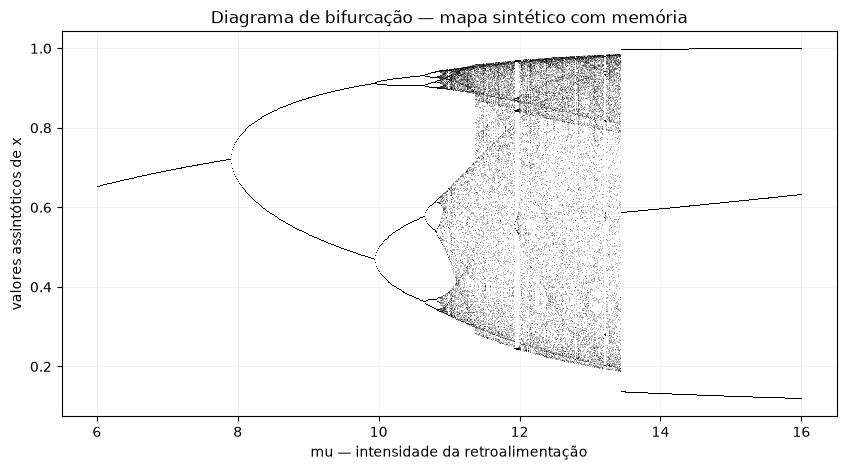

In [11]:
# Célula 11 — diagrama de bifurcação do mapa com memória
mu_grid = np.linspace(6.0, 16.0, 750)
mu_pts=[]
x_pts=[]

for mu in mu_grid:
    tr = simulate_map(mu, n=1400, discard=1150)
    vals = tr[-140:,0]
    mu_pts.extend([mu]*len(vals))
    x_pts.extend(vals)

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(mu_pts, x_pts, ',k', alpha=0.28)
ax.set_xlabel("mu — intensidade da retroalimentação")
ax.set_ylabel("valores assintóticos de x")
ax.set_title("Diagrama de bifurcação — mapa sintético com memória")
ax.grid(alpha=0.15)
plt.show()

# Parte C — Expoente de Lyapunov: primeiro pela equação, depois pelos dados

Se conhecemos as equações do sistema, podemos acompanhar o crescimento de uma perturbação infinitesimal. Para o mapa

$$
\mathbf z_{n+1}=F(\mathbf z_n),
$$

uma perturbação pequena evolui aproximadamente como

$$
\delta\mathbf z_{n+1}\approx J(\mathbf z_n)\delta\mathbf z_n.
$$

Após muitas iterações,

$$
\delta\mathbf z_n\approx
J(\mathbf z_{n-1})\cdots J(\mathbf z_1)J(\mathbf z_0)\delta\mathbf z_0.
$$

O maior expoente de Lyapunov mede a taxa exponencial média de crescimento na direção que mais se expande:

$$
\lambda_{\max}=\lim_{n\to\infty}\frac1n
\ln\frac{\|\delta\mathbf z_n\|}{\|\delta\mathbf z_0\|}.
$$

Na prática, se deixarmos o vetor crescer livremente, ocorrerão problemas numéricos. Por isso normalizamos o vetor tangente a cada iteração e acumulamos os logaritmos dos fatores de expansão.

In [12]:
# Célula 12 — maior expoente de Lyapunov via dinâmica tangente (Benettin)

def lyapunov_tangent(mu, z0=(0.30,0.31), n=7000, transient=1000):
    z = np.array(z0, dtype=float)
    v = np.array([1.0, 0.0])
    total = 0.0
    count = 0

    for i in range(n):
        J = J_map(z, mu)
        z = F_map(z, mu)

        w = J @ v
        norm_w = np.linalg.norm(w)
        norm_w = max(norm_w, 1e-300)
        v = w / norm_w

        if i >= transient:
            total += np.log(norm_w)
            count += 1

    return total/count

for mu in [7.0, 8.0, 10.0, 11.0, 11.5, 12.5, 14.0]:
    print(f"mu={mu:4.1f}  lambda_max={lyapunov_tangent(mu): .4f}")

mu= 7.0  lambda_max=-0.4255
mu= 8.0  lambda_max=-0.1075
mu=10.0  lambda_max=-0.0409
mu=11.0  lambda_max= 0.0926
mu=11.5  lambda_max= 0.2897
mu=12.5  lambda_max= 0.3476
mu=14.0  lambda_max=-0.0670


### Interpretação

- $\lambda_{\max}<0$: trajetórias próximas tendem a se contrair no atrator;
- $\lambda_{\max}=0$: situação limítrofe, frequentemente associada a transições/bifurcações;
- $\lambda_{\max}>0$: há expansão exponencial média de pequenas perturbações — **dependência sensível às condições iniciais**.

No modelo conhecido, um valor positivo é evidência forte de caos determinístico. Em **dados reais**, porém, a interpretação é muito mais delicada: ruído, não-estacionariedade, sazonalidade, tamanho finito da série e parâmetros de reconstrução podem produzir estimativas enganosas.

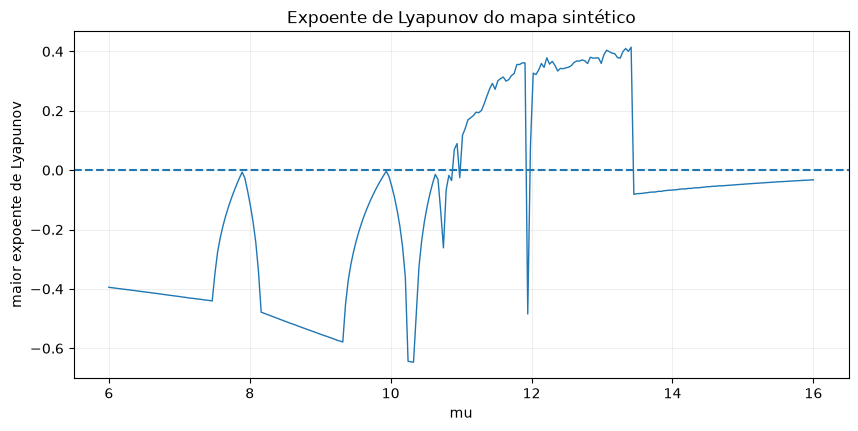

In [13]:
# Célula 13 — espectro de lambda_max ao variar mu
mu_lyap = np.linspace(6.0, 16.0, 260)
lyaps = np.array([lyapunov_tangent(mu, n=4200, transient=700) for mu in mu_lyap])

fig, ax = plt.subplots(figsize=(10,4.5))
ax.plot(mu_lyap, lyaps, lw=1)
ax.axhline(0, ls='--')
ax.set_xlabel("mu")
ax.set_ylabel("maior expoente de Lyapunov")
ax.set_title("Expoente de Lyapunov do mapa sintético")
ax.grid(alpha=0.2)
plt.show()

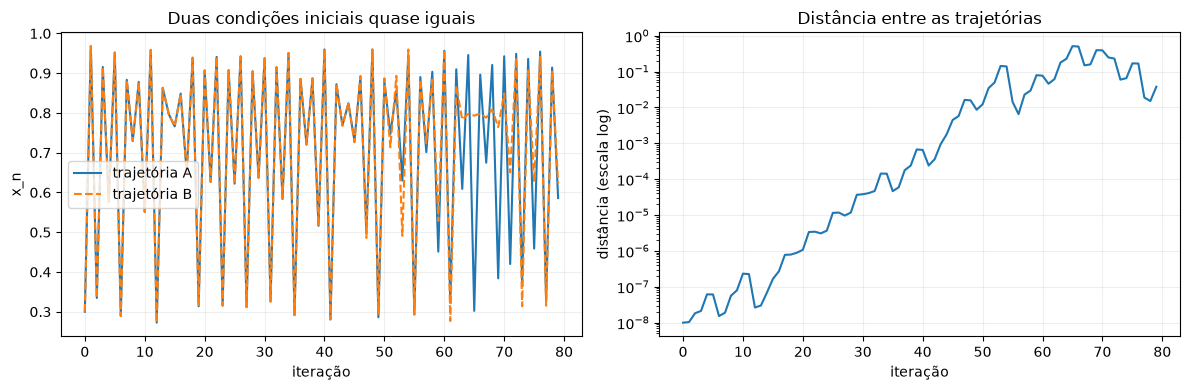

In [14]:
# Célula 14 — sensibilidade às condições iniciais em um regime caótico
mu_c = 11.5
z1 = np.array([0.30000000, 0.31000000])
z2 = np.array([0.30000001, 0.31000000])

D=[]
X1=[]
X2=[]
for n in range(80):
    X1.append(z1[0]); X2.append(z2[0])
    D.append(np.linalg.norm(z2-z1))
    z1 = F_map(z1, mu_c)
    z2 = F_map(z2, mu_c)

D = np.array(D)

fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].plot(X1, label="trajetória A")
axes[0].plot(X2, '--', label="trajetória B")
axes[0].set_title("Duas condições iniciais quase iguais")
axes[0].set_xlabel("iteração")
axes[0].set_ylabel("x_n")
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].semilogy(np.maximum(D,1e-16))
axes[1].set_title("Distância entre as trajetórias")
axes[1].set_xlabel("iteração")
axes[1].set_ylabel("distância (escala log)")
axes[1].grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Parte D — Agora fingimos que as equações são desconhecidas

Até aqui usamos $F$ e sua Jacobiana. Com dados ambientais reais, essa informação não estará disponível. Em geral teremos apenas uma ou mais séries temporais.

Aqui faremos um experimento controlado: simularemos o mapa, **esconderemos a equação** e manteremos apenas a série escalar $x_n$.

Como o estado verdadeiro do nosso sistema é

$$
(x_n,x_{n-1}),
$$

podemos reconstruí-lo diretamente com coordenadas defasadas:

$$
\mathbf X_n=(x_n,x_{n-\tau}).
$$

Neste exemplo sintético, sabemos que $\tau=1$ é natural porque o próprio modelo possui memória de um passo. Em dados reais, $\tau$ e a dimensão de imersão precisam ser estimados/justificados.

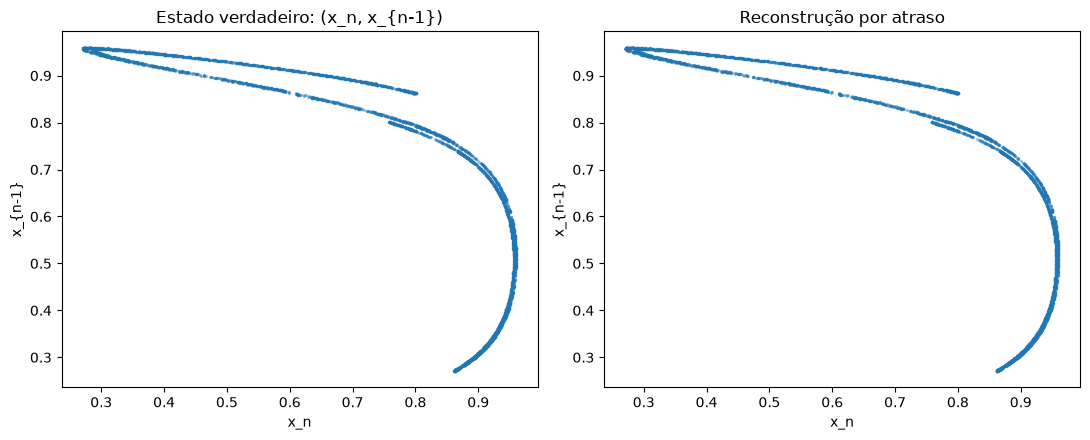

In [15]:
# Célula 15 — função de delay embedding

def delay_embedding(series, emb_dim=2, lag=1):
    x = np.asarray(series, dtype=float)
    nvec = len(x) - (emb_dim-1)*lag
    if nvec <= 0:
        raise ValueError("Série curta demais para emb_dim e lag escolhidos.")
    return np.column_stack([
        x[(emb_dim-1-j)*lag:(emb_dim-1-j)*lag+nvec]
        for j in range(emb_dim)
    ])

tr = simulate_map(mu_c, n=5500, discard=1000)
scalar = tr[:,0]
X = delay_embedding(scalar, emb_dim=2, lag=1)

fig, axes = plt.subplots(1,2, figsize=(11,4.5))
axes[0].scatter(tr[1:,0], tr[:-1,0], s=2, alpha=0.35)
axes[0].set_title("Estado verdadeiro: (x_n, x_{n-1})")
axes[0].set_xlabel("x_n"); axes[0].set_ylabel("x_{n-1}")

axes[1].scatter(X[:,0], X[:,1], s=2, alpha=0.35)
axes[1].set_title("Reconstrução por atraso")
axes[1].set_xlabel("x_n"); axes[1].set_ylabel("x_{n-1}")
plt.tight_layout()
plt.show()

O caso acima é deliberadamente pedagógico: sabemos que a reconstrução correta é bidimensional e que o atraso natural é 1. Em dados climáticos reais, não temos esse privilégio.

Uma estratégia prática é investigar:

- atraso $\tau$: autocorrelação, informação mútua ou outros critérios;
- dimensão de imersão $m$: falsos vizinhos mais próximos ou estabilidade de invariantes;
- janela temporal de exclusão (*Theiler window*): evita usar como “vizinho” um ponto que é próximo apenas porque ocorreu imediatamente antes/depois na série.

## D.1 Estimando Lyapunov somente a partir da série — ideia de Rosenstein

A lógica é muito diferente do método pela Jacobiana:

1. reconstruímos vetores de estado $\mathbf X_i$;
2. para cada ponto, encontramos um vizinho espacial $\mathbf X_j$ que esteja suficientemente distante no tempo;
3. acompanhamos os dois estados no futuro;
4. medimos

$$
d_i(k)=\|\mathbf X_{i+k}-\mathbf X_{j+k}\|;
$$

5. se houver uma região em que

$$
d_i(k)\approx d_i(0)e^{\lambda k},
$$

então

$$
\ln d_i(k)\approx \ln d_i(0)+\lambda k.
$$

Logo, a inclinação de uma região aproximadamente linear de $\langle\ln d_i(k)\rangle$ em função de $k$ fornece uma estimativa de $\lambda$.

Essa é a matemática que bibliotecas como `nolds` automatizam em implementações de Lyapunov a partir de séries.

Lyapunov pela equação/Jacobiana : 0.2897 por iteração
Lyapunov por Rosenstein (dados): 0.2840 por iteração
pares de vizinhos usados: 1164


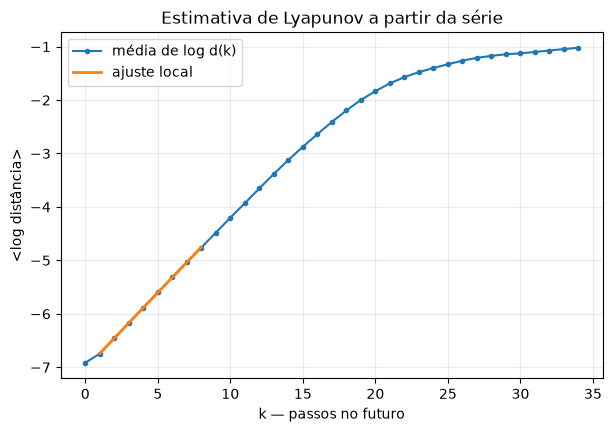

In [16]:
# Célula 16 — implementação didática de Rosenstein

def rosenstein_curve(series, emb_dim=3, lag=1, theiler=20,
                     max_k=35, max_points=1200, neighbors_to_try=30):
    X = delay_embedding(series, emb_dim=emb_dim, lag=lag)
    if len(X) > max_points:
        X = X[:max_points]

    tree = cKDTree(X)
    pairs=[]
    max_valid_i = len(X)-max_k-1

    for i in range(max_valid_i):
        # pedimos vários vizinhos e escolhemos o primeiro temporalmente permitido
        dists, inds = tree.query(X[i], k=min(neighbors_to_try, len(X)))
        inds = np.atleast_1d(inds)
        for j in inds[1:]:
            if abs(int(j)-i) > theiler and j < max_valid_i:
                pairs.append((i, int(j)))
                break

    if len(pairs) < 20:
        raise RuntimeError("Poucos pares válidos; ajuste theiler/max_points.")

    logd = np.full((len(pairs), max_k), np.nan)
    for p,(i,j) in enumerate(pairs):
        for k in range(max_k):
            dist = np.linalg.norm(X[i+k]-X[j+k])
            if dist > 0:
                logd[p,k] = np.log(dist)

    mean_logd = np.nanmean(logd, axis=0)
    return np.arange(max_k), mean_logd, pairs


def rosenstein_lyap(series, emb_dim=3, lag=1, theiler=20,
                    max_k=35, fit_range=(1,10)):
    k, mean_logd, pairs = rosenstein_curve(
        series, emb_dim=emb_dim, lag=lag, theiler=theiler, max_k=max_k
    )
    a,b = fit_range
    coef = np.polyfit(k[a:b], mean_logd[a:b], 1)
    return coef[0], k, mean_logd, coef, len(pairs)

lam_ros, k, curve, coef, npairs = rosenstein_lyap(
    scalar, emb_dim=3, lag=1, theiler=20, fit_range=(1,9)
)
lam_model = lyapunov_tangent(mu_c)

print(f"Lyapunov pela equação/Jacobiana : {lam_model:.4f} por iteração")
print(f"Lyapunov por Rosenstein (dados): {lam_ros:.4f} por iteração")
print(f"pares de vizinhos usados: {npairs}")

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(k, curve, 'o-', ms=3, label="média de log d(k)")
a,b = 1,9
ax.plot(k[a:b], np.polyval(coef, k[a:b]), lw=2, label="ajuste local")
ax.set_xlabel("k — passos no futuro")
ax.set_ylabel("<log distância>")
ax.set_title("Estimativa de Lyapunov a partir da série")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

### Por que os dois valores não precisam coincidir exatamente?

O método tangente usa a dinâmica verdadeira e a Jacobiana exata. O método de Rosenstein usa apenas uma série finita, uma reconstrução escolhida por nós, vizinhos aproximados e uma janela de ajuste escolhida manualmente.

Essa diferença é **didaticamente central** para o TCC: calcular um expoente de Lyapunov de uma equação conhecida e estimá-lo de dados observados são problemas matemáticos diferentes.

## D.2 Comparação opcional com `nolds`

A célula abaixo usa `nolds.lyap_r` **somente se a biblioteca estiver instalada**. Se necessário, você pode instalar no seu ambiente com:

```python
%pip install nolds
```

Não fizemos a instalação automaticamente para manter o notebook executável também em ambientes sem acesso à internet.

In [17]:
# Célula 17 — comparação opcional com nolds
try:
    import nolds
    HAS_NOLDS = True
except Exception as exc:
    HAS_NOLDS = False
    print("nolds não está disponível neste ambiente.")
    print("Instale com: %pip install nolds")

if HAS_NOLDS:
    # tau=1 => unidade do resultado é "por amostra/iteração"
    lam_nolds = nolds.lyap_r(
        scalar[:3500],
        emb_dim=3,
        lag=1,
        min_tsep=20,
        trajectory_len=20,
        fit="poly",
        tau=1
    )
    print(f"nolds.lyap_r = {lam_nolds:.4f} por iteração")
    print(f"manual Rosenstein = {lam_ros:.4f}")
    print(f"modelo/Jacobiana = {lam_model:.4f}")

nolds não está disponível neste ambiente.
Instale com: %pip install nolds


# Parte E — O que muda quando a série parece mais “ambiental”?

Dados ambientais reais têm sazonalidade, ruído instrumental, lacunas, tendências, autocorrelação e mudanças de regime. O próprio projeto do TCC prevê avaliar essas características antes da análise não linear.

Vamos contaminar deliberadamente a série caótica com:

$$
\text{observado}_n=x_n+A\sin\left(\frac{2\pi n}{T}\right)+\eta_n,
$$

onde $\eta_n$ é ruído gaussiano.

Também criaremos uma série AR(1), que é **estocástica** e fortemente autocorrelacionada. Isso serve para mostrar um perigo: uma série irregular não é automaticamente caótica.

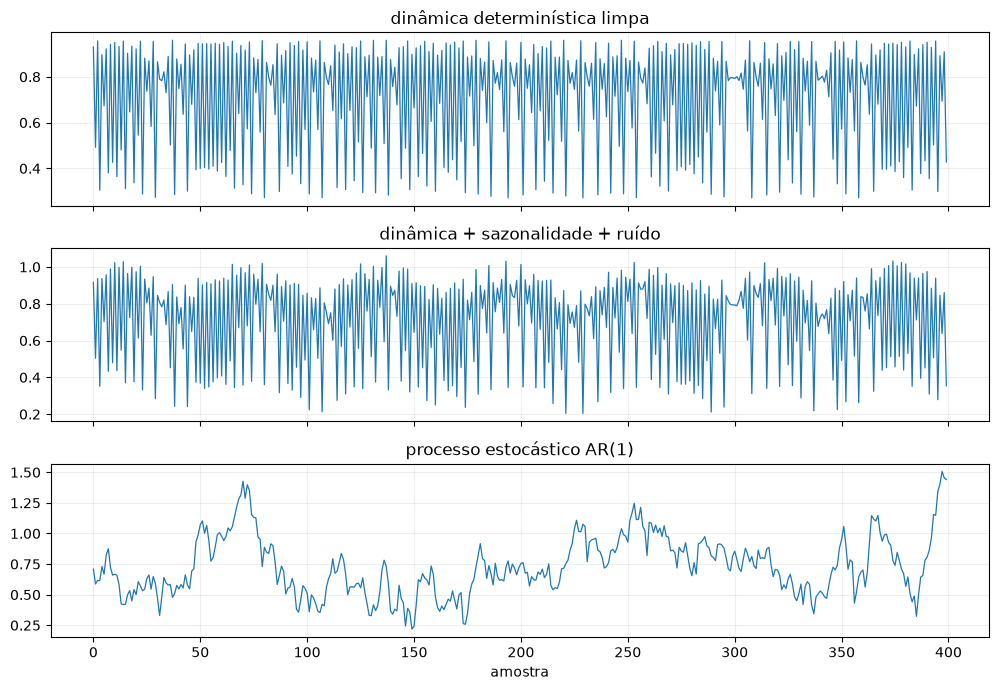

In [18]:
# Célula 18 — série observada com sazonalidade + ruído e uma série AR(1)
N = 3500
clean = scalar[:N].copy()
t = np.arange(N)
season = 0.07*np.sin(2*np.pi*t/60)
noise = 0.018*rng.normal(size=N)
observed = clean + season + noise

# AR(1) com média e variância semelhantes
phi = 0.92
ar = np.empty(N)
ar[0] = np.mean(clean)
eps = rng.normal(scale=np.std(clean)*np.sqrt(1-phi**2), size=N)
for i in range(1,N):
    ar[i] = np.mean(clean) + phi*(ar[i-1]-np.mean(clean)) + eps[i]

fig, axes = plt.subplots(3,1,figsize=(10,7),sharex=True)
for ax, s, title in zip(axes,
                        [clean, observed, ar],
                        ["dinâmica determinística limpa",
                         "dinâmica + sazonalidade + ruído",
                         "processo estocástico AR(1)"]):
    ax.plot(s[:400], lw=0.9)
    ax.set_title(title)
    ax.grid(alpha=0.2)
axes[-1].set_xlabel("amostra")
plt.tight_layout()
plt.show()

In [19]:
# Célula 19 — como a estimativa de Lyapunov reage?
series_dict = {
    "determinístico limpo": clean,
    "com sazonalidade+ruído": observed,
    "AR(1) estocástico": ar,
}

rows=[]
for name,s in series_dict.items():
    try:
        val, *_ = rosenstein_lyap(s, emb_dim=3, lag=1, theiler=25,
                                  max_k=30, fit_range=(1,8))
    except Exception:
        val = np.nan
    rows.append({"série":name, "lambda_Rosenstein":val})

pd.DataFrame(rows)

,série,lambda_Rosenstein
0,determinístico limpo,0.285394
1,com sazonalidade+ruído,0.245283
2,AR(1) estocástico,0.192371


Se uma série estocástica ou uma série contaminada também produzir uma inclinação positiva em algum intervalo, isso **não prova caos**. O resultado deve ser confrontado com outras evidências e com hipóteses nulas apropriadas.

É por isso que o projeto do TCC menciona procedimentos complementares como séries substitutas e gráficos de recorrência.

## E.1 Série substituta por randomização de fase

Uma série substituta (*surrogate*) é construída para preservar algumas propriedades lineares do sinal — por exemplo, aproximadamente o espectro de potência — enquanto destrói relações de fase específicas.

Aqui construiremos uma versão simples por randomização das fases de Fourier. Isso não é um teste estatístico completo, mas mostra a lógica: **comparar uma estatística não linear do dado com a mesma estatística em dados que preservam parte de sua estrutura linear**.

Rosenstein — série original : 0.2854
Rosenstein — surrogate      : 0.1373


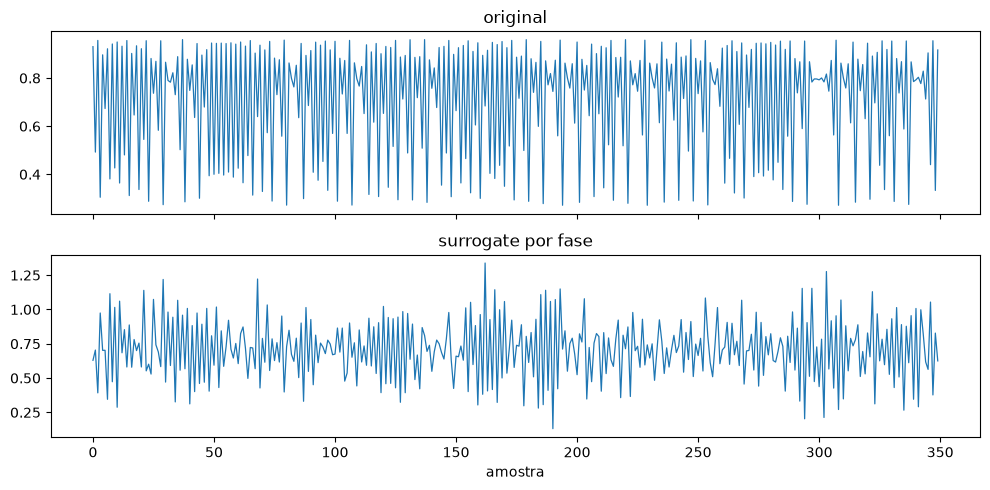

In [20]:
# Célula 20 — surrogate com fases aleatórias

def phase_randomized_surrogate(x, rng):
    x = np.asarray(x)
    mean = x.mean()
    Xf = np.fft.rfft(x-mean)
    amp = np.abs(Xf)
    phase = np.angle(Xf)

    new_phase = rng.uniform(0, 2*np.pi, len(Xf))
    new_phase[0] = phase[0]
    if len(x) % 2 == 0:
        new_phase[-1] = phase[-1]

    Yf = amp*np.exp(1j*new_phase)
    return np.fft.irfft(Yf, n=len(x)) + mean

sur = phase_randomized_surrogate(clean, rng)

lam_clean, *_ = rosenstein_lyap(clean, emb_dim=3, lag=1, theiler=25, max_k=30, fit_range=(1,8))
lam_sur, *_ = rosenstein_lyap(sur, emb_dim=3, lag=1, theiler=25, max_k=30, fit_range=(1,8))

print(f"Rosenstein — série original : {lam_clean:.4f}")
print(f"Rosenstein — surrogate      : {lam_sur:.4f}")

fig, axes = plt.subplots(2,1,figsize=(10,5),sharex=True)
axes[0].plot(clean[:350], lw=0.9); axes[0].set_title("original")
axes[1].plot(sur[:350], lw=0.9); axes[1].set_title("surrogate por fase")
axes[1].set_xlabel("amostra")
plt.tight_layout()
plt.show()

Não devemos interpretar uma única comparação de surrogate como teste definitivo. Em uma análise real, geraríamos um **conjunto** de séries substitutas, definiríamos previamente uma estatística e uma hipótese nula, e avaliaríamos se o valor observado é incompatível com a distribuição obtida para os surrogates.

## E.2 Gráfico de recorrência

Depois de reconstruir o espaço de estados, podemos perguntar quando o sistema retorna a uma região já visitada.

Definimos uma matriz de recorrência simples por

$$
R_{ij}=\begin{cases}
1,&\|\mathbf X_i-\mathbf X_j\|<\varepsilon,\\
0,&\text{caso contrário.}
\end{cases}
$$

O gráfico de $R_{ij}$ revela estruturas temporais que não aparecem diretamente na série escalar.

/tmp/ipykernel_305450/2792707007.py:5: DeprecationWarning: `distance_matrix` is deprecated in favor of `scipy.spatial.distance.cdist` as of SciPy 1.18.0 and will be removed in SciPy 1.20.0.
  D = distance_matrix(X, X)
/tmp/ipykernel_305450/2792707007.py:5: DeprecationWarning: `minkowski_distance` is deprecated in favor of `scipy.spatial.distance.minkowski` as of SciPy 1.18.0 and will be removed in SciPy 1.20.0.
  D = distance_matrix(X, X)
/tmp/ipykernel_305450/2792707007.py:5: DeprecationWarning: `minkowski_distance_p` is deprecated in favor of `scipy.spatial.distance.minkowski` as of SciPy 1.18.0 and will be removed in SciPy 1.20.0.
  D = distance_matrix(X, X)


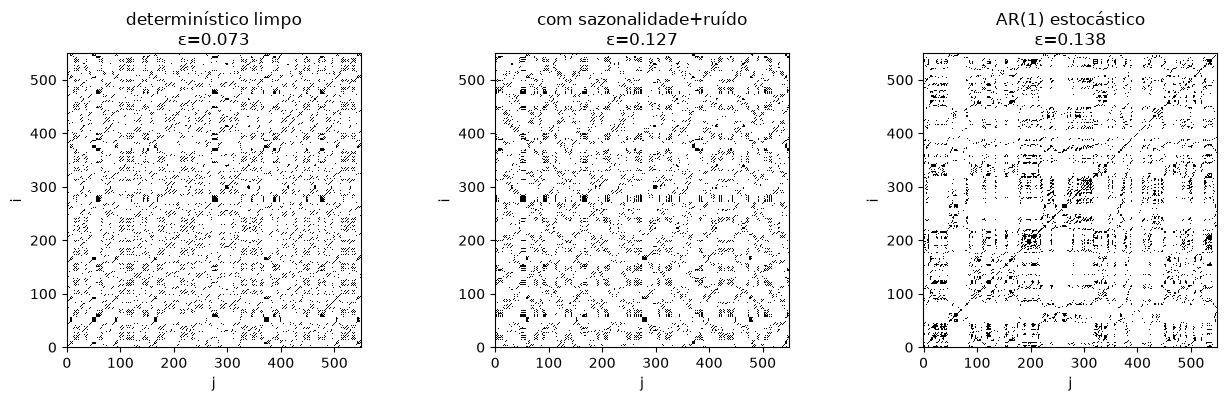

In [21]:
# Célula 21 — gráfico de recorrência simples

def recurrence_matrix(series, emb_dim=3, lag=1, npoints=550, quantile=0.08):
    X = delay_embedding(series, emb_dim=emb_dim, lag=lag)[:npoints]
    D = distance_matrix(X, X)
    # limiar baseado apenas nas distâncias fora da diagonal
    vals = D[np.triu_indices_from(D, k=1)]
    eps = np.quantile(vals, quantile)
    R = D < eps
    return R, eps

fig, axes = plt.subplots(1,3,figsize=(13,4))
for ax,(name,s) in zip(axes, series_dict.items()):
    R, eps = recurrence_matrix(s)
    ax.imshow(R, origin='lower', cmap='binary', interpolation='nearest')
    ax.set_title(name + f"\nε={eps:.3f}")
    ax.set_xlabel("j"); ax.set_ylabel("i")
plt.tight_layout()
plt.show()

### O que observar nos gráficos de recorrência?

Não procure apenas “qual figura parece mais bonita”. Em análises quantitativas, usam-se métricas como taxa de recorrência, determinismo, comprimento de linhas diagonais e laminaridade.

Aqui o objetivo é apenas desenvolver a intuição de que duas séries com irregularidade visual semelhante podem apresentar **organizações temporais diferentes no espaço reconstruído**.

# Parte F — Um roteiro de trabalho para dados reais do TCC

A sequência abaixo é uma proposta metodológica de estudo, não uma receita automática:

1. **Definir a variável e a escala temporal.** Ex.: precipitação diária? umidade mensal? temperatura horária?
2. **Inspecionar qualidade da série.** Lacunas, outliers, mudanças instrumentais, resolução.
3. **Caracterizar tendência e sazonalidade.** Não aplicar uma ferramenta de caos ignorando ciclos sazonais óbvios.
4. **Verificar extensão da série.** Reconstruções e expoentes exigem dados suficientes.
5. **Escolher atraso e dimensão de imersão.** Justificar $\tau$ e $m$, não apenas usar defaults de biblioteca.
6. **Reconstruir o espaço de estados.** Inspecionar geometria, recorrências e robustez.
7. **Estimar Lyapunov por mais de uma configuração.** Verificar estabilidade em relação a parâmetros do estimador.
8. **Construir séries substitutas.** Perguntar se o resultado excede o que uma hipótese linear/estocástica explicaria.
9. **Comparar regiões e períodos.** No contexto do TCC, isso pode ser feito entre áreas com níveis distintos de perturbação.
10. **Interpretar com cautela.** Um resultado numérico não deve ser chamado de “caos” ou “tipping point” sem evidências convergentes.

# Exercícios guiados

### Exercício 1 — estabilidade no contínuo
Altere $d$ no modelo contínuo. Recalcule $P_c$. Aumentar $d$ desloca o limiar para qual direção? Explique usando a fórmula antes de simular.

### Exercício 2 — memória no mapa discreto
Altere $\kappa$ de 1.0 para 0.2, 0.6, 1.4. Refaça o diagrama de bifurcação. A memória retardada torna a dinâmica mais ou menos complexa?

### Exercício 3 — previsão versus Lyapunov
Escolha um $\mu$ com $\lambda_{max}>0$. Modifique a diferença inicial entre duas trajetórias de $10^{-8}$ para $10^{-5}$. A taxa de crescimento muda? E o tempo até as trajetórias parecerem completamente diferentes?

### Exercício 4 — reconstrução
No método de Rosenstein, varie `emb_dim`, `lag`, `theiler` e a janela `fit_range`. Quão robusta é a estimativa?

### Exercício 5 — ruído
Aumente o ruído observacional de 0.018 para 0.05 e 0.10. Em que ponto a estimativa baseada em dados deixa de representar bem o expoente conhecido do modelo?

### Exercício 6 — teste com surrogates
Gere 30 surrogates por randomização de fase. Construa a distribuição das estimativas de Lyapunov e compare o valor da série original. Isso já constitui um teste válido para todos os tipos de não linearidade? Por quê?

# Perguntas úteis para discutir com o orientador

- Para quais variáveis do TCC faz sentido buscar uma dinâmica autônoma aproximada, e para quais o forçamento externo domina?
- Qual deve ser a escala temporal de amostragem para não confundir sazonalidade com dinâmica interna?
- Pretendemos estimar Lyapunov apenas como ferramenta exploratória ou como resultado central?
- Qual estratégia será usada para selecionar $\tau$, dimensão de imersão e *Theiler window*?
- Precisamos comparar estimadores diferentes de Lyapunov?
- Qual hipótese nula será usada para as séries substitutas?
- Como separar “perda de previsibilidade”, “aumento de variabilidade”, “bifurcação” e “tipping point” na redação final?
- É melhor analisar cada variável isoladamente ou reconstruir estados multivariados quando houver séries sincronizadas?

# Síntese matemática para o caderno

**Sistema contínuo:**

$$
\dot{\mathbf x}=f(\mathbf x),
\quad
\delta\dot{\mathbf x}\approx J(\mathbf x^*)\delta\mathbf x.
$$

Estabilidade local: partes reais dos autovalores negativas.

**Mapa discreto:**

$$
\mathbf x_{n+1}=F(\mathbf x_n),
\quad
\delta\mathbf x_{n+1}\approx J(\mathbf x_n)\delta\mathbf x_n.
$$

Ponto fixo estável: autovalores da Jacobiana com módulo menor que 1.

**Bifurcação:** mudança qualitativa da dinâmica quando um parâmetro cruza um valor crítico.

**Maior expoente de Lyapunov:**

$$
\lambda_{max}>0
\quad\Rightarrow\quad
\text{separação exponencial média de trajetórias próximas}.
$$

**Reconstrução por atraso:**

$$
\mathbf X_n=[x_n,x_{n-\tau},\ldots,x_{n-(m-1)\tau}].
$$

**Ideia prática principal:** antes de aplicar uma biblioteca a dados climáticos, entender qual grandeza matemática ela está tentando aproximar e quais hipóteses podem falhar.

## Referências de estudo usadas como ponto de partida

- CIPOLLI, V. G. *Sistemas Dinâmicos Discretos – análise de estabilidade*. Dissertação de Mestrado, UNESP, 2012. Ver especialmente as seções sobre pontos de equilíbrio/estabilidade, critérios de estabilidade, ciclos e bifurcações.
- PROTO, V. G. *Estudo de estabilidade e bifurcações em sistemas não-lineares*. Dissertação de Mestrado, 2013. Ver especialmente os capítulos sobre retrato de fase, linearização, mapas, estabilidade, mapa logístico, expoentes de Lyapunov e crises.
- Projeto de TCC: *Uma Análise do Sistema Floresta-Atmosfera Amazônica sob a ótica da Teoria do Caos*. O projeto propõe reconstrução do espaço de fases, maior expoente de Lyapunov e métodos complementares como recorrência e séries substitutas.

Para uma implementação científica final, consulte também as referências metodológicas originais dos estimadores utilizados e valide cuidadosamente os parâmetros de análise.